In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

# Check how the models behave when we train an all the models except 7

In [ ]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

X_train = mnist_train.data.float() / 255.0 # normalize between 0 and 1
y_train = mnist_train.targets.long()
X_test = mnist_test.data.float() / 255.0
y_test = mnist_test.targets.long()

# drop the cases of 7s but just on the train set
X_train = X_train[y_train!=7]
y_train = y_train[y_train!=7]

# and test just on 7s
X_test = X_test[y_test==7]
y_test = y_test[y_test==7]

In [3]:
# Convert into pytorch tensors
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)

In [4]:
class MNIST_FNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 64) 
        self.fc2 = nn.Linear(64, 32) 
        self.fc3 = nn.Linear(32, 32)  
        self.fc4 = nn.Linear(32, 10)    

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return x

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs):
    
    train_acc = np.zeros(epochs)
    test_acc = np.zeros(epochs)
    losses = np.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses

In [5]:
# Experiment
learning_rate = 0.01
epochs = 50

# IMPORTANT: the loss fun can be reused for multiple models, it doesnt store any state,
# but the optimizer needs to be redefined for each model since it stores the state of the parameters
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss combines nn.LogSoftmax() and nn.NLLLoss()

model = MNIST_FNN()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, loss_fn, epochs) 

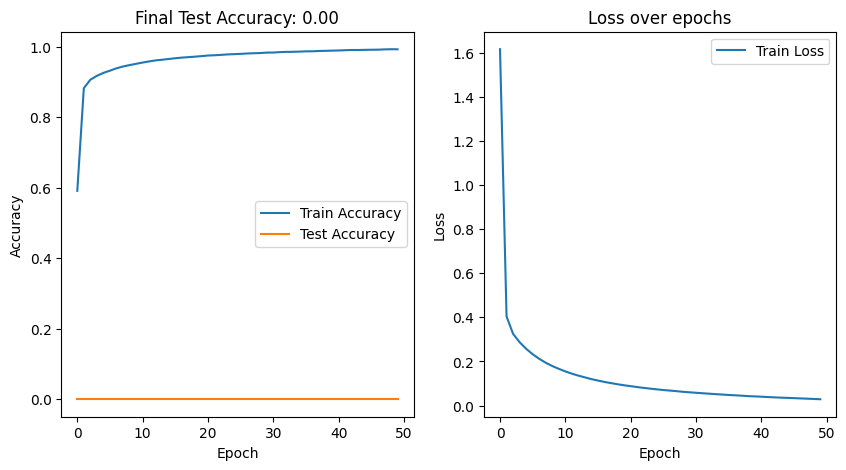

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(train_acc, label="Train Accuracy")
ax[0].plot(test_acc, label="Test Accuracy")
ax[0].set_title(f"Final Test Accuracy: {test_acc[-1]:.2f}")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(losses, label="Train Loss")
ax[1].set_title("Loss over epochs")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.show()

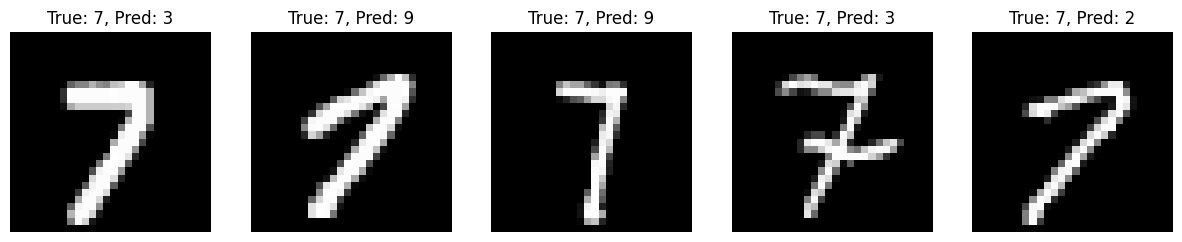

In [ ]:
# plot the images and the labels predicted by the model
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = X_test[i].reshape(28, 28)
    true_label = y_test[i].item()
    with torch.no_grad():
        pred_label = model(X_test[i].unsqueeze(0)).argmax(dim=1).item()
    
    ax[i].imshow(img, cmap="gray")
    ax[i].set_title(f"True: {true_label}, Pred: {pred_label}")
    ax[i].axis("off")

# more or less the model will try to approximate the 7s to the most similar number

(array([  2.,  12., 104., 245.,  18.,   2.,   3.,   0.,  13., 228.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5]),
 <BarContainer object of 10 artists>)

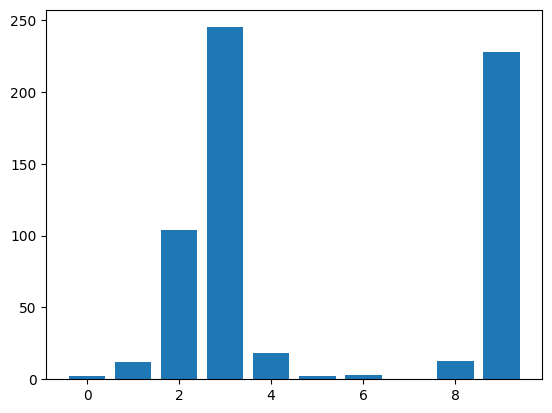

In [9]:
# show the frequency of the predicted labels
pred_labels = model(X_test).argmax(dim=1)
plt.hist(pred_labels.cpu().numpy(), bins=np.arange(11)-0.5, rwidth=0.8)

# 7 is most similar to 9, 2 or 3 following the model logics